# Effect of Missing Data on Decision Tree Performance

## Introduction

Previous experiments showed that missing data slightly reduced the performance of a Logistic Regression classifier.

However, different machine learning algorithms may respond differently to incomplete datasets.

The objective of this experiment is to investigate how different levels of missing data affect the performance of a Decision Tree classifier using the Titanic dataset.

## Import Libraries

The following libraries are required for data preprocessing, model training, evaluation, and visualization.

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import matplotlib.pyplot as plt

## Load Dataset

The Titanic dataset is loaded into a pandas DataFrame and will be used throughout the experiment.

In [21]:
df = pd.read_csv("Titanic-Dataset.csv")

## Data Preparation

Before introducing missing values, the dataset is preprocessed.

Categorical variables are converted into numerical values using one-hot encoding, and unnecessary columns are removed.

The Age column is intentionally left unchanged because missing values will be introduced and handled during the experiment.

In [22]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df,columns=["Sex", "Embarked"],drop_first=True)

df = df.drop(columns=[ "PassengerId", "Name","Ticket", "Cabin"])

## Create Evaluation Function

A function is created to simulate different levels of missing data, preprocess the dataset, train a Decision Tree classifier, and evaluate its performance.

Using a function allows the same experiment to be repeated for different percentages of missing values under identical conditions.

In [23]:
def evaluate_missing_data(df, missing_fraction):

    data = df.copy()

    missing_indexes = data.sample(frac=missing_fraction, random_state=42).index

    data.loc[ missing_indexes,"Age"] = np.nan

    data["Age"] = data["Age"].fillna( data["Age"].median())

    X = data.drop(columns=["Survived"])
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp}

## Evaluate Different Missing Data Levels

The Decision Tree model is evaluated using four versions of the dataset containing 0%, 10%, 20%, and 30% missing values.

The results are stored for comparison.

In [26]:
results = []

missing_levels = [0, 0.1, 0.2,0.3]

for level in missing_levels:

    result = evaluate_missing_data(df, level)

    result["Missing Data"] = f"{int(level*100)}%"

    results.append(result)

## Create Comparison Table

The evaluation results are converted into a pandas DataFrame to compare the performance of the Decision Tree classifier under different levels of missing data.

In [27]:
comparison = pd.DataFrame(results)

comparison = comparison[["Missing Data", "Accuracy", "Precision", "Recall", "F1-score", "True Negative", "False Positive","False Negative","True Positive"]]

comparison = comparison.round(3)

comparison

,Missing Data,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0,0%,0.782,0.727,0.757,0.742,84,21,18,56
1,10%,0.810,0.763,0.784,0.773,87,18,16,58
2,20%,0.793,0.761,0.730,0.745,88,17,20,54
3,30%,0.788,0.781,0.676,0.725,91,14,24,50


## Analysis of Results

The experiment demonstrates that the Decision Tree classifier responds differently to missing data compared with Logistic Regression.

Interestingly, the highest model performance was achieved when 10% missing values were introduced. At this level, the model reached its best Accuracy (0.810), Recall (0.784), and F1-score (0.773). This suggests that a small amount of missing data, followed by median imputation, did not negatively affect the model and may have slightly reduced overfitting.

When the percentage of missing values increased to 20% and 30%, the model performance gradually decreased. Accuracy fell from 0.810 to 0.788, while Recall decreased from 0.784 to 0.676. As a result, the F1-score also dropped from 0.773 to 0.725.

The confusion matrix supports these findings. At 30% missing data, the number of False Negatives increased from 16 to 24, while the number of correctly classified positive cases decreased from 58 to 50. This indicates that the model became less effective at identifying passengers who survived.

Overall, the Decision Tree classifier appears to be relatively robust to moderate levels of missing data, but excessive missing information still reduces prediction quality.

## Conclusion

This experiment investigated the effect of missing data on the performance of a Decision Tree classifier.

The results showed that introducing a small proportion of missing values (10%) did not reduce model performance. Instead, the classifier achieved its highest Accuracy and F1-score at this level. However, larger amounts of missing data gradually reduced Recall and overall predictive performance.

Compared with the Logistic Regression experiment, the Decision Tree classifier demonstrated greater robustness to missing data. These findings suggest that different machine learning algorithms react differently to incomplete datasets and should be evaluated individually when data quality issues are present.

## Accuracy Comparison

The following graph illustrates how different levels of missing data influence the Accuracy of the Decision Tree classifier.

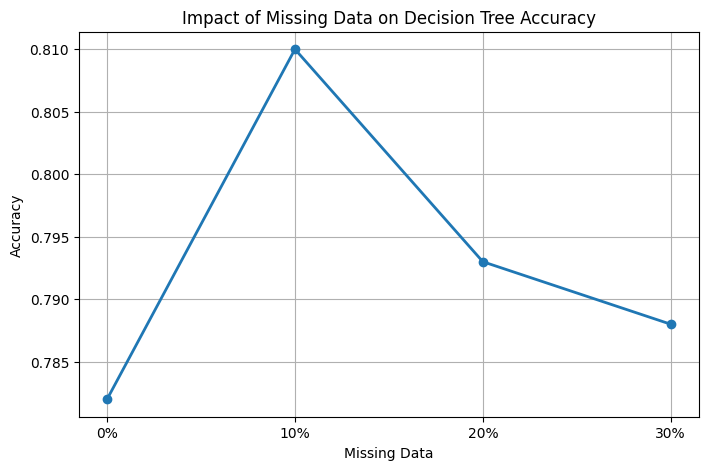

In [31]:
plt.figure(figsize=(8,5))

plt.plot(comparison["Missing Data"], comparison["Accuracy"], marker="o", linewidth=2)

plt.xlabel("Missing Data")
plt.ylabel("Accuracy")
plt.title("Impact of Missing Data on Decision Tree Accuracy")

plt.grid(True)

plt.savefig("decision_tree_missing_accuracy.png")

plt.show()

## F1-score Comparison

The following graph illustrates how different levels of missing data influence the F1-score of the Decision Tree classifier.

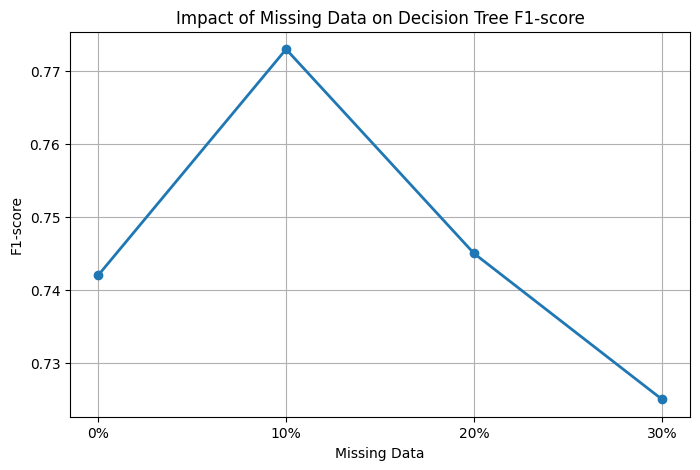

In [32]:
plt.figure(figsize=(8,5))

plt.plot(comparison["Missing Data"], comparison["F1-score"], marker="o", linewidth=2)

plt.xlabel("Missing Data")
plt.ylabel("F1-score")
plt.title("Impact of Missing Data on Decision Tree F1-score")

plt.grid(True)

plt.savefig("decision_tree_missing_f1.png")

plt.show()